<a href="https://colab.research.google.com/github/owlmt/QML/blob/main/QSVM_DDoS_Said2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum SVM for DDoS detection: coding the Said (2023) paper step by step

This notebook rebuilds the experiment in one paper from the lecture:

Dhaou Said, "Quantum Computing and Machine Learning for Cybersecurity: Distributed Denial of Service (DDoS) Attack Detection on Smart Micro Grid", *Energies* 16(8), 3572, 2023. DOI 10.3390/en16083572.

The notebook downloads the data by itself, prepares it, trains a classical SVM and a quantum SVM with Qiskit, and then redraws the three result figures of the paper. Every step has a short explanation in plain language, and each explanation points back to the lecture slides.

**How to run it.** Open the file in Google Colab (File, then Upload notebook), keep the normal CPU runtime, and choose Runtime, then Run all. No GPU and no IBM account are needed. Most of the running time goes into downloading one large CSV file.

**What you will get at the end.** Your own measured accuracy, precision, recall and running time for the quantum SVM and the classical SVM on the same data, side by side with the numbers the paper reports. Section 14 compares the two and explains which claims can and cannot be checked this way.

## 1. The paper in one page

**Problem.** A smart micro grid is a small power network (solar panels, batteries, local loads) that is controlled over a computer network. If an attacker floods that network with traffic, the controllers cannot talk to each other. This flood is a distributed denial of service (DDoS) attack. The paper wants to detect it automatically.

**Decision.** Each network flow gets one answer: +1 means attack, −1 means normal. This is binary classification, the same yes or no decision as spam filtering or fraud detection on the lecture slide.

**Method.** A quantum support vector machine (QSVM), built with IBM's open source Qiskit library and run on a simulator on a normal computer.

**Data.** The CICDDoS2019 dataset from the Canadian Institute for Cybersecurity. The author selects 2950 flows (benign traffic plus SSDP DDoS attacks) and 38 features.

**Preprocessing, as the paper lists it.** Class balancing, feature selection with dimension reduction, and data encoding.

**Claims.** Accuracy, precision and recall between 99.91% and 99.94% for the QSVM (Figure 1), a large gap over the classical SVM (Figure 2), and a 93% saving in execution time (Figure 3).

We will follow these steps in order and check each claim with real code.

## 2. Install the libraries

Colab already has NumPy, pandas, scikit learn and Matplotlib. We add:

* `qiskit`, to build and simulate quantum circuits;
* `qiskit_machine_learning`, which has the ready made quantum kernel and QSVC classes;
* `pylatexenc`, which Qiskit uses to draw circuits as pictures;
* `huggingface_hub`, to download the dataset.

If Colab asks you to restart the session after this cell, accept, then run the notebook again from the next cell.

In [ ]:
%pip install qiskit qiskit_machine_learning pylatexenc huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.3/282.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.2 MB/s eta 0:00:00


## 3. Settings

All the numbers you may want to change are in this one cell.

* `N_SAMPLES = 2950` and `N_FEATURES = 38` copy the paper.
* `N_QUBITS = 4` is our choice. The paper does not say how many qubits it used. Every qubit holds one number of the input, so four qubits means we compress the 38 features into 4 numbers. Four qubits keep the simulation fast on a laptop or in Colab.
* `BANDWIDTH` is explained in Section 10.5. The notebook chooses it automatically.
* `DATA_SOURCE` tells the notebook where to find the data. Leave it as `"huggingface"` to download automatically. Use `"upload"` if you want to upload a CSV file from your own computer, or `"path"` if the file is already on the Colab disk.

In [ ]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay)

from qiskit import QuantumCircuit
from qiskit.circuit.library import zz_feature_map
from qiskit.quantum_info import Statevector
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from qiskit_machine_learning.algorithms import QSVC

warnings.filterwarnings("ignore")

SEED = 42            # makes random choices repeatable
N_SAMPLES = 2950     # total flows used, as in the paper
N_FEATURES = 38      # features kept after selection, as in the paper
N_QUBITS = 4         # our choice: one qubit per compressed feature
TEST_SIZE = 0.30     # 70% of flows for training, 30% for testing
N_RUNS = 10          # repeated experiments for the Figure 1 style plot
BANDWIDTH = 1.0      # multiplies the angles before they enter the circuit (Section 10.5)
BANDWIDTH_CHOICES = [1.0, 0.5, 0.25, 0.1]

DATA_SOURCE = "huggingface"            # "huggingface", "upload" or "path"
LOCAL_PATH = "/content/DrDoS_SSDP.csv" # used only when DATA_SOURCE == "path"
HF_REPO = "baalajimaestro/CICDDoS2019" # public copy of the original CSV files

LABEL_NAMES = ["normal (−1)", "attack (+1)"]

def seconds_since(start):
    # time passed since `start`, in seconds
    return float(np.subtract(time.perf_counter(), start))

## 5. Get the data

### What CICDDoS2019 is

The Canadian Institute for Cybersecurity at the University of New Brunswick built a test network, ran normal user traffic through it, and launched 12 kinds of DDoS attack against it during one day of recording (Sharafaldin et al., ICCST 2019). The traffic was cut into **flows**. A flow is one conversation between two computers: same source, same destination, same ports, same protocol. The tool CICFlowMeter then measured more than 80 numbers for each flow, for example how long it lasted, how many packets went each way, and the average packet size. Each row of the CSV file is one flow, and the `Label` column says whether it was benign or which attack it belonged to.

### What an SSDP attack is

SSDP is the protocol that home devices such as printers and smart TVs use to announce themselves on a network. In an SSDP reflection attack, the attacker sends many small requests to such devices while pretending to be the victim. The devices answer with much larger replies, and all those replies land on the victim. The attacker spends little bandwidth and the victim receives a flood.

### How the download works

The original files are large (about 22 GB for the first day). The file we need, `DrDoS_SSDP.csv`, holds millions of flows, almost all of them attacks. The code below:

1. finds that file in a public Hugging Face copy of the dataset and downloads it;
2. reads it in pieces of 200,000 rows so that Colab memory does not fill up;
3. keeps every benign flow and a 2% random sample of the attack flows.

The SSDP file contains far more attack flows than benign ones. If it does not hold enough benign flows for a balanced sample, the code takes the missing benign flows from the smallest other file of the same dataset. Those flows come from the same test network and the same benign traffic generator.

If the Hugging Face copy is ever unavailable, download the CSV files from the dataset page on unb.ca (Canadian Institute for Cybersecurity, datasets, DDoS 2019), and set `DATA_SOURCE = "upload"`.

In [ ]:
ID_COLUMNS = ["Unnamed: 0", "Flow ID", "Source IP", "Source Port",
              "Destination IP", "Destination Port", "Timestamp", "SimillarHTTP"]

def list_csv_files(repo):
    # returns a list of (file path, size in bytes) for every CSV in the repository
    from huggingface_hub import HfApi
    found = []
    for item in HfApi().list_repo_tree(repo, repo_type="dataset", recursive=True):
        if item.path.lower().endswith(".csv"):
            found.append((item.path, getattr(item, "size", None) or 0))
    return found

def download(repo, filename):
    from huggingface_hub import hf_hub_download
    print("Downloading", filename, "...")
    return hf_hub_download(repo_id=repo, filename=filename, repo_type="dataset")

def read_flows(csv_path, attack_fraction, benign_needed=None):
    # Read a large CICDDoS2019 CSV in pieces.
    # Keep all benign flows and a random fraction of the SSDP attack flows.
    # If benign_needed is given, stop as soon as that many benign flows are found.
    kept, n_benign = [], 0
    for chunk in pd.read_csv(csv_path, chunksize=200_000, low_memory=False):
        chunk.columns = chunk.columns.str.strip()   # original headers start with spaces
        label = chunk["Label"].astype(str).str.strip().str.upper()
        benign = chunk[label == "BENIGN"]
        kept.append(benign)
        n_benign += len(benign)
        if attack_fraction > 0:
            attack = chunk[label.str.contains("SSDP")]
            kept.append(attack.sample(frac=attack_fraction, random_state=SEED))
        if benign_needed is not None and n_benign >= benign_needed:
            break
    return pd.concat(kept, ignore_index=True)

start = time.perf_counter()
if DATA_SOURCE == "huggingface":
    csv_files = list_csv_files(HF_REPO)
    for path, size in csv_files:
        print(f"{size / 1e9:6.2f} GB   {path}")
    ssdp_file = [p for p, s in csv_files if "SSDP" in p.upper()][0]
    main_csv = download(HF_REPO, ssdp_file)
elif DATA_SOURCE == "upload":
    from google.colab import files
    main_csv = list(files.upload().keys())[0]
else:
    main_csv = LOCAL_PATH

raw = read_flows(main_csv, attack_fraction=0.02)

per_class = N_SAMPLES // 2
n_benign = int((raw["Label"].astype(str).str.strip().str.upper() == "BENIGN").sum())
print("Benign flows found in the SSDP file:", n_benign)

if n_benign < per_class and DATA_SOURCE == "huggingface":
    missing = int(np.subtract(per_class, n_benign))
    others = sorted((size, path) for path, size in csv_files if "SSDP" not in path.upper())
    extra_file = others[0][1]    # the smallest other file
    print(f"Taking {missing} more benign flows from {extra_file}")
    extra = read_flows(download(HF_REPO, extra_file), attack_fraction=0, benign_needed=missing)
    raw = pd.concat([raw, extra.head(missing)], ignore_index=True)

print(f"Loaded {len(raw):,} flows in {seconds_since(start):.0f} s")
raw["Label"].astype(str).str.strip().value_counts()

  2.13 GB   01-12/DrDoS_DNS.csv
  0.92 GB   01-12/DrDoS_LDAP.csv
  1.89 GB   01-12/DrDoS_MSSQL.csv
  0.65 GB   01-12/DrDoS_NTP.csv
  1.70 GB   01-12/DrDoS_NetBIOS.csv
  2.17 GB   01-12/DrDoS_SNMP.csv
  1.25 GB   01-12/DrDoS_SSDP.csv
  1.51 GB   01-12/DrDoS_UDP.csv
  0.64 GB   01-12/Syn.csv
  9.30 GB   01-12/TFTP.csv
  0.16 GB   01-12/UDPLag.csv
  0.87 GB   03-11/LDAP.csv
  2.39 GB   03-11/MSSQL.csv
  1.42 GB   03-11/NetBIOS.csv
  0.08 GB   03-11/Portmap.csv
  1.88 GB   03-11/Syn.csv
  1.79 GB   03-11/UDP.csv
  0.32 GB   03-11/UDPLag.csv


01-12/DrDoS_SSDP.csv: reconstructing file:   0%|          |  0.00B / 1.25GB            

01-12/DrDoS_SSDP.csv: downloading bytes:           |  0.00B            

Benign flows found in the SSDP file: 763
Taking 712 more benign flows from 03-11/Portmap.csv


03-11/Portmap.csv: reconstructing file:   0%|          |  0.00B / 78.6MB            

03-11/Portmap.csv: downloading bytes:           |  0.00B            

Loaded 53,689 flows in 88 s


,count
Label,
DrDoS_SSDP,52214
BENIGN,1475


### A first look

Each row is one flow and each column is one measurement. The last column is the label. Look at a few columns and notice how different the scales are: durations in microseconds reach millions, while flag counts are 0 or 1. We will fix this in the preprocessing step.

In [ ]:
print(raw.shape)
raw[["Flow Duration", "Total Fwd Packets", "Total Backward Packets",
     "Fwd Packet Length Mean", "Flow Bytes/s", "Label"]].head(8)

(53689, 88)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packet Length Mean,Flow Bytes/s,Label
0,65833,10,7,2131.000000,334604.225844,BENIGN
1,17614,3,0,239.333333,40763.029408,BENIGN
2,7235010,2,8,0.000000,0.000000,BENIGN
3,7234413,2,8,0.000000,0.000000,BENIGN
4,7234114,2,8,0.000000,0.000000,BENIGN
5,7230012,2,8,0.000000,0.000000,BENIGN
6,42122,3,16,0.000000,693224.443284,BENIGN
7,55607,1,3,0.000000,0.000000,BENIGN


## 6. From labels to +1 and −1

The lecture writes the SVM with labels +1 and −1. Here attack is +1 and normal is −1. Scikit learn works just as well with 1 and 0 and does the conversion inside, so in the code we store 1 for attack and 0 for normal. Keep in mind that 0 in the code means −1 in the formulas.

**Cleaning.** Some flows contain impossible values, such as an infinite number of bytes per second when a flow lasted 0 microseconds. We remove those rows. We also remove the identifier columns (IP addresses, ports, timestamps). They are not behaviour, and a model that learns "this IP address is the attacker" would fail on any other network.

In [ ]:
df = raw.copy()
df["Label"] = df["Label"].astype(str).str.strip().str.upper()
y_all = pd.Series(np.where(df["Label"] == "BENIGN", 0, 1), name="y")

X_all = df.drop(columns=ID_COLUMNS + ["Label"], errors="ignore")
X_all = X_all.apply(pd.to_numeric, errors="coerce")
X_all = X_all.replace([np.inf, np.negative(np.inf)], np.nan)

good = X_all.notna().all(axis=1)
X_all, y_all = X_all[good].reset_index(drop=True), y_all[good].reset_index(drop=True)

X_all = X_all.loc[:, X_all.nunique() > 1]     # a column that never changes carries no information
print("Flows after cleaning:", len(X_all), "   numeric features:", X_all.shape[1])
print(y_all.value_counts().rename({0: "normal", 1: "attack"}))

Flows after cleaning: 52844    numeric features: 67
y
attack    51378
normal     1466
Name: count, dtype: int64


## 7. Preprocessing: the three steps of the paper

### Step 1, class balancing

If 99% of the flows were attacks, a model that always answers "attack" would score 99% accuracy and learn nothing. Balancing means we take the same number of normal and attack flows. With 2950 flows that is 1475 of each.

In [ ]:
per_class = int(min(N_SAMPLES // 2, (y_all == 0).sum(), (y_all == 1).sum()))
idx_normal = y_all[y_all == 0].sample(per_class, random_state=SEED).index
idx_attack = y_all[y_all == 1].sample(per_class, random_state=SEED).index
keep = idx_normal.union(idx_attack)

X, y = X_all.loc[keep].reset_index(drop=True), y_all.loc[keep].reset_index(drop=True)
print(f"Balanced dataset: {len(X)} flows, {per_class} normal and {per_class} attack")

Balanced dataset: 2932 flows, 1466 normal and 1466 attack


### Step 2, feature selection and dimension reduction

A four qubit circuit can take only four numbers, but we have about 80 features. We shrink them in two moves.

* **Feature selection.** `SelectKBest` scores each feature by how differently it behaves in the two classes (an F test) and keeps the best 38, as in the paper.
* **Dimension reduction.** Principal component analysis (PCA) mixes those 38 features into 4 new numbers that keep as much of the spread in the data as possible. Before PCA we standardise every feature (mean 0, spread 1), otherwise the feature with the largest units would dominate.

### Step 3, data encoding

Each of the 4 numbers will become a rotation angle on one qubit. Rotations repeat every 2π, so we rescale every number into the range 0 to π.

**One rule that matters a lot.** All of these steps are learned from the training flows only, then applied unchanged to the test flows. If the test flows help choose the features or the scaling, information from the exam leaks into the study material, and the results look better than they really are.

In [ ]:
def prepare(X, y, seed):
    # split, then learn every preprocessing step on the training part only
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=seed)

    selector = SelectKBest(f_classif, k=min(N_FEATURES, X.shape[1])).fit(X_tr, y_tr)
    scaler = StandardScaler().fit(selector.transform(X_tr))
    pca = PCA(n_components=N_QUBITS, random_state=seed).fit(
        scaler.transform(selector.transform(X_tr)))
    reduced_tr = pca.transform(scaler.transform(selector.transform(X_tr)))
    to_angles = MinMaxScaler(feature_range=(0, np.pi)).fit(reduced_tr)

    def encode(Z):
        Z = pca.transform(scaler.transform(selector.transform(Z)))
        return np.clip(to_angles.transform(Z), 0, np.pi)

    return encode(X_tr), encode(X_te), y_tr.to_numpy(), y_te.to_numpy(), selector, pca

X_train, X_test, y_train, y_test, selector, pca = prepare(X, y, SEED)

print("Training flows:", X_train.shape, "   test flows:", X_test.shape)
print("The 38 selected features include:", list(X.columns[selector.get_support()])[:8], "...")
print("Share of the spread kept by the 4 PCA components:",
      np.round(pca.explained_variance_ratio_, 3), "total", round(pca.explained_variance_ratio_.sum(), 3))

Training flows: (2052, 4)    test flows: (880, 4)
The 38 selected features include: ['Protocol', 'Flow Duration', 'Total Backward Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Min'] ...
Share of the spread kept by the 4 PCA components: [0.313 0.207 0.129 0.07 ] total 0.718


The plot below shows the first two of our four numbers for every training flow. If the two colours already sit in different places, the classification task is easy. Keep this picture in mind when you read the accuracy numbers later.

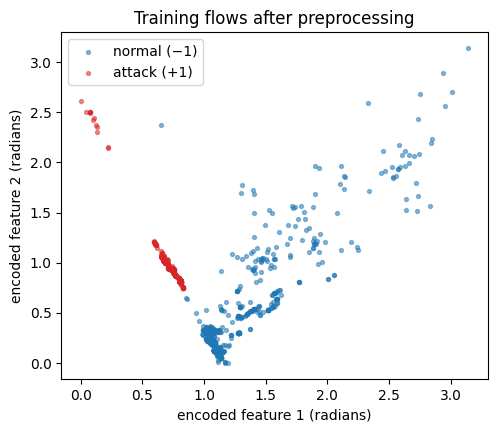

In [ ]:
plt.figure(figsize=(5.5, 4.5))
for cls, colour in [(0, "tab:blue"), (1, "tab:red")]:
    pts = X_train[y_train == cls]
    plt.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.5, c=colour, label=LABEL_NAMES[cls])
plt.xlabel("encoded feature 1 (radians)")
plt.ylabel("encoded feature 2 (radians)")
plt.title("Training flows after preprocessing")
plt.legend()
plt.show()

## 8. The optimisation view of machine learning

The lecture wrote every ML model as one recipe:

θ* = arg min over θ of [ (1/n) Σᵢ L(f_θ(xᵢ), yᵢ) + λ R(θ) ]

In words: try parameter values θ, make predictions, measure how wrong they are with a loss L, average over the data, add a penalty R for complexity, and keep the parameters with the smallest total.

The SVM is one choice for each ingredient:

* **model:** a straight boundary, f(x) = wᵀx + b, and the prediction is the sign of f(x);
* **loss:** the hinge loss, L = max(0, 1 − y·f(x)). It is zero when a point is on the correct side by a margin of at least 1, and grows in a straight line otherwise;
* **regulariser:** L2, R(w) = ½‖w‖². Small weights mean a wide margin and a simpler boundary.

The paper writes the same problem in its Equation (2), with slack variables ξ that measure how far each point breaks the margin, and a constant C that plays the role of 1/λ.

The next cell checks the number example from the slide: model f(x) = x, λ = 1, three points with label +1.

In [ ]:
x_points = np.array([3.0, 0.5, np.negative(1.0)])   # the three points on the slide
y_points = np.array([1, 1, 1])                        # all labelled +1
w, b, lam = 1.0, 0.0, 1.0

f = w * x_points + b
margin = y_points * f
hinge = np.maximum(0, np.subtract(1, margin))

print("margins    :", margin)
print("hinge loss :", hinge)
print("average hinge =", round(hinge.mean(), 2))
print("L2 penalty    =", lam / 2 * w ** 2)
print("objective     =", round(hinge.mean() + lam / 2 * w ** 2, 2))

margins    : [ 3.   0.5 -1. ]
hinge loss : [0.  0.5 2. ]
average hinge = 0.83
L2 penalty    = 0.5
objective     = 1.33


The output matches the slide: average hinge 0.83, penalty 0.5, objective 1.33. The first point is safely correct, the second is correct but too close to the boundary, and the third is on the wrong side, so it costs the most.

## 9. The classical SVM baseline

A straight line cannot separate every dataset. The **kernel trick** fixes this. The SVM never needs the data points themselves, only how similar each pair of points is. That similarity is the kernel K(xᵢ, xⱼ). A kernel quietly maps the data into a bigger space where a straight boundary works, then brings the answer back as a curved boundary in the original space. The optimisation problem stays the same. Only the kernel, which is the geometry the classifier sees, changes.

We train two classical SVMs on exactly the same four numbers the quantum model will get: one with a linear kernel and one with the common RBF (Gaussian) kernel. We time the training and the prediction, because the paper compares execution time. The paper uses C = 1, so we do the same.

In [ ]:
def evaluate(y_true, y_pred):
    return {"accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0)}

results, timings, predictions = {}, {}, {}

for name, kernel in [("SVM linear", "linear"), ("SVM RBF", "rbf")]:
    start = time.perf_counter()
    model = SVC(kernel=kernel, C=1.0).fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    timings[name] = seconds_since(start)
    results[name] = evaluate(y_test, predictions[name])

pd.DataFrame(results).T.style.format("{:.4f}")

,accuracy,precision,recall
SVM linear,1.0000,1.0000,1.0000
SVM RBF,1.0000,1.0000,1.0000


## 10. From the kernel SVM to the quantum SVM

This is the central idea of the lecture:

K(xᵢ, xⱼ)  →  K_Q(xᵢ, xⱼ)

We keep the classical SVM optimiser and replace only the kernel with one computed by a quantum circuit. The pipeline is:

classical data → quantum feature map → quantum circuit → kernel K_Q → classical SVM optimiser → prediction.

Before building it, here are the quantum ideas from Section 3 of the paper, one at a time.

### 10.1 Qubits and superposition

A classical bit is 0 or 1. A qubit has a state |φ⟩ = α|0⟩ + β|1⟩. The numbers α and β are called amplitudes. When we measure, we get 0 with probability |α|² and 1 with probability |β|², and these two probabilities add up to 1 (paper, Equations 9 and 14).

### 10.2 Gates

Gates change the state. The paper lists the usual ones. Three appear in our circuit:

* **Hadamard (H)** turns |0⟩ into an equal mix of |0⟩ and |1⟩. Measure it and you get 0 or 1 with 50% each.
* **Phase gate P(θ)** leaves |0⟩ alone and turns |1⟩ into e^(iθ)|1⟩. Measuring right away shows no change, but the phase matters once later gates mix the states. This is where our data enters the circuit.
* **CNOT** acts on two qubits. It flips the second qubit only when the first one is 1. This links qubits together (entanglement).

The next cell shows each gate on a tiny circuit and prints the measurement probabilities.

In [ ]:
def show_probabilities(circuit, title):
    probs = Statevector(circuit).probabilities_dict()
    print(f"{title:32s}", {str(k): round(float(v), 3) for k, v in probs.items()})

qc = QuantumCircuit(1)
show_probabilities(qc, "nothing applied to |0>")

qc = QuantumCircuit(1); qc.x(0)
show_probabilities(qc, "X (NOT) on |0>")

qc = QuantumCircuit(1); qc.h(0)
show_probabilities(qc, "H on |0>")

qc = QuantumCircuit(1); qc.h(0); qc.p(np.pi, 0); qc.h(0)
show_probabilities(qc, "H, phase pi, H")

qc = QuantumCircuit(2); qc.h(0); qc.cx(0, 1)
show_probabilities(qc, "H then CNOT (entangled pair)")

nothing applied to |0>           {'0': 1.0}
X (NOT) on |0>                   {'1': 1.0}
H on |0>                         {'0': 0.5, '1': 0.5}
H, phase pi, H                   {'0': 0.0, '1': 1.0}
H then CNOT (entangled pair)     {'00': 0.5, '11': 0.5}


Read the output line by line. H gives 50/50. Adding a phase of π between two H gates turns the result into a certain 1: the phase was invisible on its own but changed the final answer. The last line is an entangled pair, where only 00 or 11 can appear, never 01 or 10.

Qiskit prints qubit 0 as the **rightmost** character of each bit string.

### 10.3 The quantum feature map

The feature map is the circuit U_φ(x) that loads one data point into the qubits. We use Qiskit's ZZ feature map, the standard choice in quantum kernel papers:

1. H on every qubit, to create superposition;
2. P(2xₖ) on qubit k, so each feature becomes a phase;
3. for each neighbouring pair of qubits, a CNOT, a phase that depends on the product of two features, and another CNOT. This is how the circuit captures interactions between features;
4. repeat the whole block twice (`reps=2`).

The result is the quantum state |φ(x)⟩ = U_φ(x)|0000⟩. It lives in a space of 2⁴ = 16 complex amplitudes. That space is the quantum feature space.

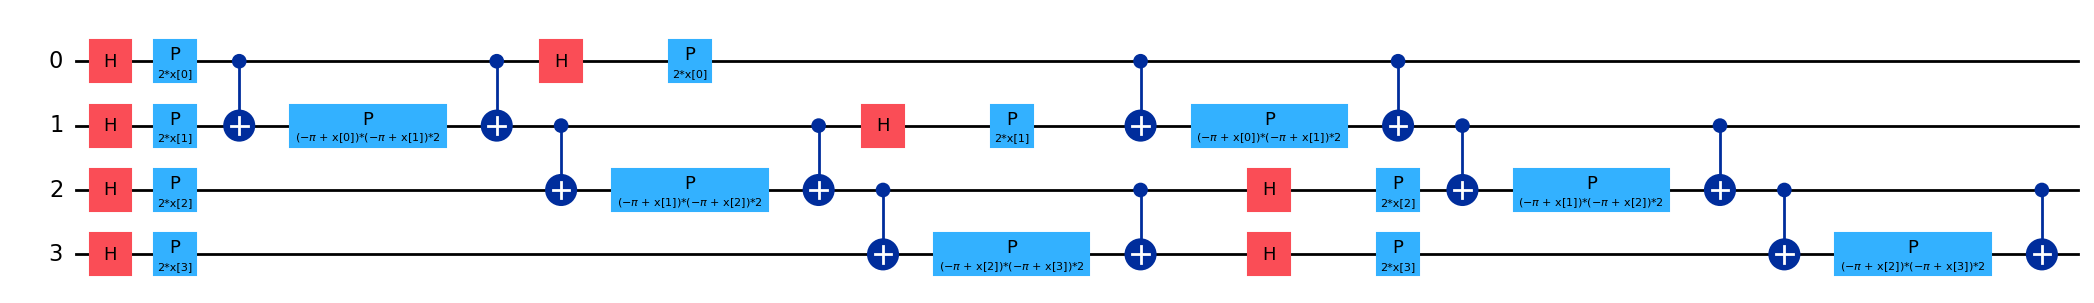

In [ ]:
feature_map = zz_feature_map(feature_dimension=N_QUBITS, reps=2, entanglement="linear")
feature_map.draw("mpl", fold=40)

Now load one real training flow into the circuit and look at the resulting state. The bars are the 16 measurement probabilities. A different flow gives a different pattern.

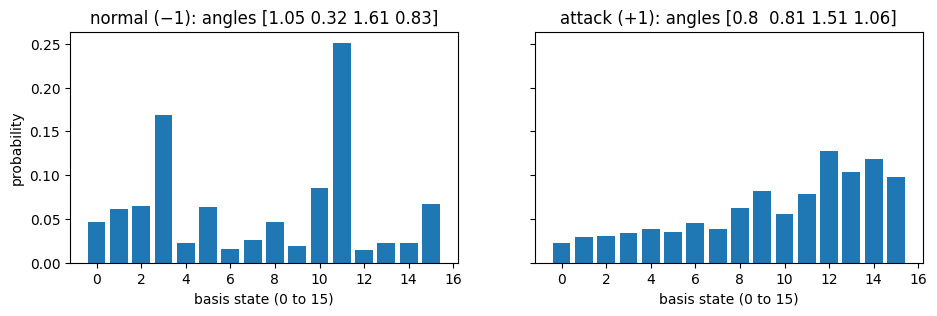

In [ ]:
def quantum_state(x):
    # |phi(x)> = U(x)|0000>, returned as a vector of 16 complex amplitudes
    return Statevector(feature_map.assign_parameters(x * BANDWIDTH)).data

def quantum_states(X_rows):
    return np.array([quantum_state(x) for x in X_rows])

first_normal = X_train[y_train == 0][0]
first_attack = X_train[y_train == 1][0]

fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
for ax, x, name in [(axes[0], first_normal, LABEL_NAMES[0]), (axes[1], first_attack, LABEL_NAMES[1])]:
    ax.bar(range(2 ** N_QUBITS), np.abs(quantum_state(x)) ** 2)
    ax.set_title(f"{name}: angles {np.round(x, 2)}")
    ax.set_xlabel("basis state (0 to 15)")
axes[0].set_ylabel("probability")
plt.show()

### 10.4 The quantum kernel

The lecture defines the quantum kernel as

K_Q(xᵢ, xⱼ) = |⟨φ(xᵢ)|φ(xⱼ)⟩|²

It measures how much two quantum states overlap: 1 when they are identical and close to 0 when they are very different. On real hardware you run U_φ(xⱼ), then the inverse of U_φ(xᵢ), and count how often all qubits come back as 0. On a simulator we can compute it exactly from the amplitudes.

The next cell computes the kernel by hand, then asks Qiskit's `FidelityStatevectorKernel` for the same numbers. They must agree.

In [ ]:
def quantum_kernel(states_a, states_b):
    # K_Q = |<phi(a)|phi(b)>|^2 for every pair of rows
    return np.abs(states_a.conj() @ states_b.T) ** 2

pair = np.array([first_normal, first_attack])
S_pair = quantum_states(pair)
by_hand = quantum_kernel(S_pair, S_pair)
qiskit_kernel = FidelityStatevectorKernel(feature_map=feature_map)
from_qiskit = qiskit_kernel.evaluate(pair)

print("kernel by hand:\n", np.round(by_hand, 4))
print("kernel from Qiskit:\n", np.round(from_qiskit, 4))
print("same result:", np.allclose(by_hand, from_qiskit))

kernel by hand:
 [[1.     0.1815]
 [0.1815 1.    ]]
kernel from Qiskit:
 [[1.     0.1815]
 [0.1815 1.    ]]
same result: True


The diagonal is 1 because every state overlaps perfectly with itself. The off diagonal number tells us how similar the normal flow and the attack flow look to the quantum circuit.

Below is the kernel matrix for 30 normal and 30 attack flows. A good kernel shows two bright squares: flows of the same class look similar to each other and different from the other class.

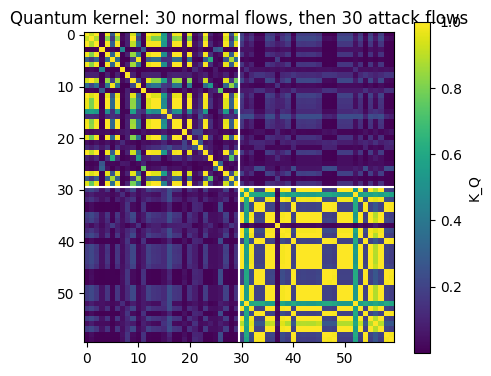

In [ ]:
sample = np.vstack([X_train[y_train == 0][:30], X_train[y_train == 1][:30]])
S_sample = quantum_states(sample)
K_sample = quantum_kernel(S_sample, S_sample)

plt.figure(figsize=(5, 4.3))
plt.imshow(K_sample, cmap="viridis")
plt.colorbar(label="K_Q")
plt.axhline(29.5, color="white"); plt.axvline(29.5, color="white")
plt.title("Quantum kernel: 30 normal flows, then 30 attack flows")
plt.show()

### 10.5 Kernel bandwidth: how far apart the states should be

Look at the kernel values above. If almost every pair of different flows has a kernel value near 0, the SVM sees every flow as unlike every other flow. It can then memorise the training data but has little to say about a new flow. Quantum kernels fall into this trap easily, because a few rotations are enough to make two states almost orthogonal.

A simple fix is to shrink all angles by a factor before they enter the circuit. We call that factor the bandwidth. A smaller bandwidth keeps the states closer together and the kernel values larger. It plays the same role as the width parameter of the classical RBF kernel.

We pick the bandwidth fairly: we split the **training** flows once more into a fitting part and a validation part, try each candidate, and keep the one with the best validation accuracy. The test flows are not used.

In [ ]:
def choose_bandwidth(X_part, y_part, seed, verbose=False):
    global BANDWIDTH
    X_fit, X_val, y_fit, y_val = train_test_split(
        X_part, y_part, test_size=0.3, stratify=y_part, random_state=seed)
    scores = {}
    for choice in BANDWIDTH_CHOICES:
        BANDWIDTH = choice
        S_fit, S_val = quantum_states(X_fit), quantum_states(X_val)
        K_fit = quantum_kernel(S_fit, S_fit)
        model = SVC(kernel="precomputed", C=1.0).fit(K_fit, y_fit)
        scores[choice] = model.score(quantum_kernel(S_val, S_fit), y_val)
        if verbose:
            print(f"bandwidth {choice:<5}  validation accuracy {scores[choice]:.4f}"
                  f"   average kernel value {K_fit.mean():.3f}")
    BANDWIDTH = max(scores, key=scores.get)
    return BANDWIDTH

choose_bandwidth(X_train, y_train, SEED, verbose=True)
print("chosen bandwidth:", BANDWIDTH)

bandwidth 1.0    validation accuracy 0.9968   average kernel value 0.259
bandwidth 0.5    validation accuracy 0.9968   average kernel value 0.400
bandwidth 0.25   validation accuracy 1.0000   average kernel value 0.540
bandwidth 0.1    validation accuracy 0.9984   average kernel value 0.852
chosen bandwidth: 0.25


## 11. Train the quantum SVM

### 11.1 With Qiskit's QSVC class

`QSVC` is a scikit learn SVM whose kernel is the quantum kernel. It computes K_Q for every pair of training flows (millions of pairs here), hands that matrix to the usual SVM solver, and later computes K_Q between each test flow and the training flows to predict. The SVM objective is classical. Only the kernel evaluation is quantum. This cell can take a minute.

In [ ]:
start = time.perf_counter()
qsvc = QSVC(quantum_kernel=FidelityStatevectorKernel(feature_map=feature_map), C=1.0)
qsvc.fit(X_train * BANDWIDTH, y_train)     # QSVC gets the same scaled angles
predictions["QSVM (Qiskit QSVC)"] = qsvc.predict(X_test * BANDWIDTH)
timings["QSVM (Qiskit QSVC)"] = seconds_since(start)
results["QSVM (Qiskit QSVC)"] = evaluate(y_test, predictions["QSVM (Qiskit QSVC)"])

print(f"time: {timings['QSVM (Qiskit QSVC)']:.1f} s")
print(results["QSVM (Qiskit QSVC)"])

time: 70.4 s
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0}


### 11.2 The same model, written out by hand

To make sure nothing is hidden inside `QSVC`, we repeat it in four lines: turn each flow into its quantum state once, build the kernel matrices, and give them to a normal scikit learn SVM with `kernel="precomputed"`. The predictions should be identical. This version is also faster, and we will use it for the repeated runs in Section 13.

In [ ]:
start = time.perf_counter()
S_train = quantum_states(X_train)   # quantum_state already applies BANDWIDTH
S_test = quantum_states(X_test)
qsvm = SVC(kernel="precomputed", C=1.0).fit(quantum_kernel(S_train, S_train), y_train)
predictions["QSVM (by hand)"] = qsvm.predict(quantum_kernel(S_test, S_train))
timings["QSVM (by hand)"] = seconds_since(start)
results["QSVM (by hand)"] = evaluate(y_test, predictions["QSVM (by hand)"])

print(f"time: {timings['QSVM (by hand)']:.1f} s")
print("predictions identical to QSVC:",
      np.array_equal(predictions["QSVM (by hand)"], predictions["QSVM (Qiskit QSVC)"]))

time: 6.5 s
predictions identical to QSVC: True


## 12. Measuring performance

### The confusion matrix

Every test flow ends up in one of four boxes. The attack class is the positive class.

* really attack, predicted attack: **true positive (TP)**;
* really attack, predicted normal: **false negative (FN)**, a missed attack;
* really normal, predicted attack: **false positive (FP)**, a false alarm;
* really normal, predicted normal: **true negative (TN)**.

A note for careful readers: Table 3 of the paper puts TN in the "positive" row and FN in the "negative" row. That is a typo. The four boxes above are the standard layout, and the paper's own Equations 25 to 27 only make sense with it.

From these four counts:

* **accuracy** = (TP + TN) / (TP + TN + FP + FN): the share of all flows labelled correctly;
* **precision** = TP / (TP + FP): when the model raises an alarm, how often it is a real attack;
* **recall** (sensitivity) = TP / (TP + FN): of all real attacks, how many the model catches.

In security, low recall means attacks slip through, and low precision means operators drown in false alarms.

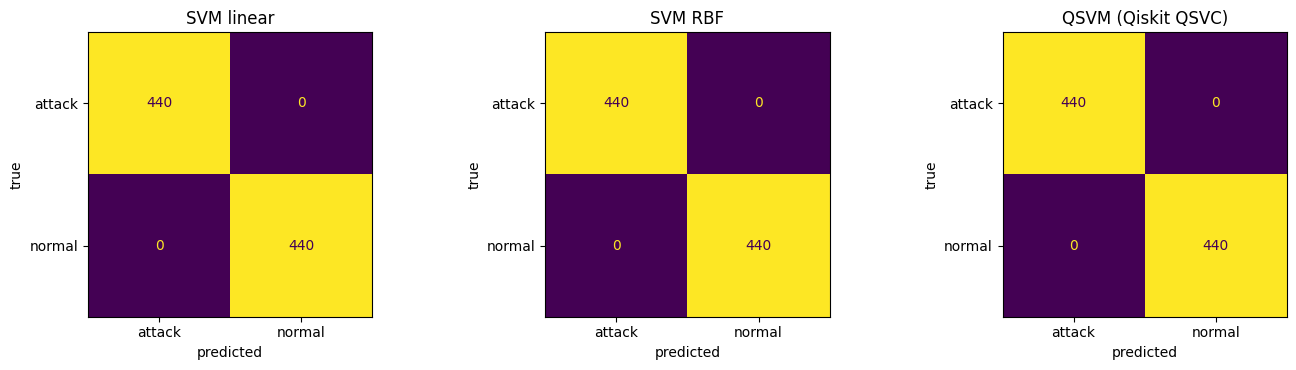

,accuracy,precision,recall,time (s)
SVM linear,1.0000,1.0000,1.0000,0.0116
SVM RBF,1.0000,1.0000,1.0000,0.0083
QSVM (Qiskit QSVC),1.0000,1.0000,1.0000,70.3540
QSVM (by hand),1.0000,1.0000,1.0000,6.4693


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, name in zip(axes, ["SVM linear", "SVM RBF", "QSVM (Qiskit QSVC)"]):
    cm = confusion_matrix(y_test, predictions[name], labels=[1, 0])
    ConfusionMatrixDisplay(cm, display_labels=["attack", "normal"]).plot(ax=ax, colorbar=False)
    ax.set_title(name); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

summary = pd.DataFrame(results).T
summary["time (s)"] = pd.Series(timings)
summary.style.format("{:.4f}")

## 13. Redrawing the three figures of the paper

### Figure 1: QSVM metrics over repeated runs

The x axis of the paper's Figure 1 is called "estimator number", but the paper never says what that is. We use the closest honest equivalent: we repeat the whole experiment 10 times with a different random train and test split each time, redo the preprocessing and the bandwidth choice each time, and plot accuracy, precision and recall for every run. The classical RBF SVM runs on the same splits, which gives us fair averages for Figure 2.

run 1: bandwidth 0.25, QSVM accuracy 1.0000, SVM accuracy 1.0000
run 2: bandwidth 1.0, QSVM accuracy 0.9989, SVM accuracy 1.0000
run 3: bandwidth 0.5, QSVM accuracy 0.9989, SVM accuracy 0.9989
run 4: bandwidth 0.5, QSVM accuracy 1.0000, SVM accuracy 1.0000
run 5: bandwidth 0.5, QSVM accuracy 0.9977, SVM accuracy 0.9977
run 6: bandwidth 1.0, QSVM accuracy 0.9977, SVM accuracy 1.0000
run 7: bandwidth 0.5, QSVM accuracy 0.9989, SVM accuracy 0.9989
run 8: bandwidth 0.5, QSVM accuracy 1.0000, SVM accuracy 0.9977
run 9: bandwidth 1.0, QSVM accuracy 0.9977, SVM accuracy 0.9989
run 10: bandwidth 0.5, QSVM accuracy 1.0000, SVM accuracy 0.9989


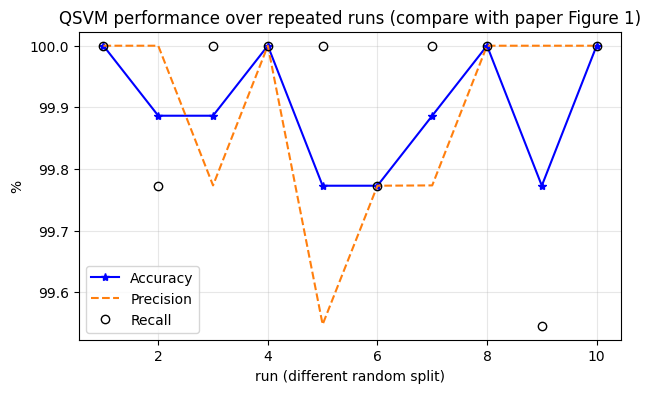

accuracy         precision          recall            time        
          mean     std      mean     std    mean     std    mean     std
model                                                                   
QSVM    0.9990  0.0010    0.9989  0.0016  0.9991  0.0016  6.1119  0.6050
SVM     0.9991  0.0009    0.9982  0.0018  1.0000  0.0000  0.0126  0.0009

In [ ]:
runs = []
for run in range(N_RUNS):
    seed = SEED + run
    Xtr, Xte, ytr, yte, _, _ = prepare(X, y, seed)

    choose_bandwidth(Xtr, ytr, seed)
    start = time.perf_counter()
    Str, Ste = quantum_states(Xtr), quantum_states(Xte)
    q_pred = SVC(kernel="precomputed", C=1.0).fit(quantum_kernel(Str, Str), ytr).predict(quantum_kernel(Ste, Str))
    q_time = seconds_since(start)

    start = time.perf_counter()
    c_pred = SVC(kernel="rbf", C=1.0).fit(Xtr, ytr).predict(Xte)
    c_time = seconds_since(start)

    q_scores, c_scores = evaluate(yte, q_pred), evaluate(yte, c_pred)
    runs.append({"run": run + 1, "model": "QSVM", "time": q_time, **q_scores})
    runs.append({"run": run + 1, "model": "SVM", "time": c_time, **c_scores})
    print(f"run {run + 1}: bandwidth {BANDWIDTH}, QSVM accuracy {q_scores['accuracy']:.4f}, "
          f"SVM accuracy {c_scores['accuracy']:.4f}")

runs = pd.DataFrame(runs)
q_runs = runs[runs.model == "QSVM"]

plt.figure(figsize=(7, 4))
plt.plot(q_runs.run, q_runs.accuracy * 100, "b*", linestyle="solid", label="Accuracy")
plt.plot(q_runs.run, q_runs.precision * 100, color="tab:orange", linestyle="dashed", label="Precision")
plt.plot(q_runs.run, q_runs.recall * 100, "ko", fillstyle="none", linestyle="none", label="Recall")
plt.xlabel("run (different random split)")
plt.ylabel("%")
plt.title("QSVM performance over repeated runs (compare with paper Figure 1)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

runs.groupby("model")[["accuracy", "precision", "recall", "time"]].agg(["mean", "std"]).round(4)

### Figure 2: QSVM against the classical SVM

Read from the bars in the paper, the QSVM sits between about 96% and 100% and the classical SVM at roughly 24% (accuracy), 44% (precision) and 18% (recall). Here are the averages over our 10 runs, on identical data.

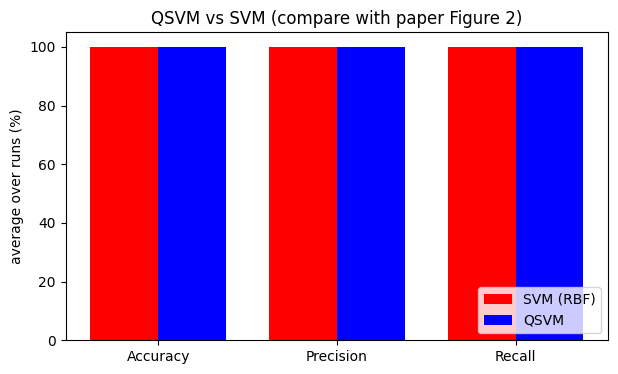

,accuracy,precision,recall
model,,,
QSVM,99.898,99.887,99.909
SVM,99.909,99.819,100.000


In [ ]:
means = runs.groupby("model")[["accuracy", "precision", "recall"]].mean() * 100
positions = np.arange(3)
width = 0.38

plt.figure(figsize=(7, 4))
plt.bar(positions, means.loc["SVM"], width, color="red", label="SVM (RBF)")
plt.bar(positions + width, means.loc["QSVM"], width, color="blue", label="QSVM")
plt.xticks(positions + width / 2, ["Accuracy", "Precision", "Recall"])
plt.ylabel("average over runs (%)")
plt.ylim(0, 105)
plt.title("QSVM vs SVM (compare with paper Figure 2)")
plt.legend(loc="lower right"); plt.show()
means.round(3)

### Figure 3: execution time

The paper reports the QSVM as 93% faster than the classical SVM. We measured training plus prediction time on the same test split for every model.

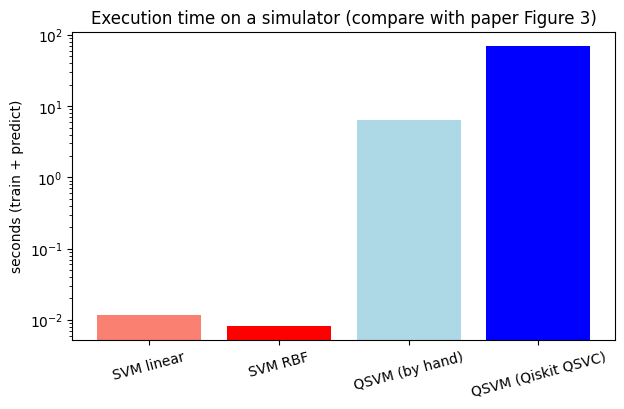

SVM linear                0.012 s   (1 times the RBF SVM)
SVM RBF                   0.008 s   (1 times the RBF SVM)
QSVM (by hand)            6.469 s   (782 times the RBF SVM)
QSVM (Qiskit QSVC)       70.354 s   (8507 times the RBF SVM)


In [ ]:
names = ["SVM linear", "SVM RBF", "QSVM (by hand)", "QSVM (Qiskit QSVC)"]
plt.figure(figsize=(7, 4))
plt.bar(names, [timings[n] for n in names], color=["salmon", "red", "lightblue", "blue"])
plt.ylabel("seconds (train + predict)")
plt.yscale("log")
plt.title("Execution time on a simulator (compare with paper Figure 3)")
plt.xticks(rotation=15); plt.show()

for n in names:
    print(f"{n:22s} {timings[n]:8.3f} s   ({timings[n] / timings['SVM RBF']:.0f} times the RBF SVM)")

## 14. Reading the paper critically

First, let the notebook compare your measured numbers with the paper's claims.

In [ ]:
q = runs[runs.model == "QSVM"][["accuracy", "precision", "recall", "time"]].mean()
c = runs[runs.model == "SVM"][["accuracy", "precision", "recall", "time"]].mean()
gap = float(np.subtract(q.accuracy, c.accuracy))

print(f"QSVM average: accuracy {q.accuracy:.2%}, precision {q.precision:.2%}, recall {q.recall:.2%}")
print(f"SVM average:  accuracy {c.accuracy:.2%}, precision {c.precision:.2%}, recall {c.recall:.2%}")
print()
print("Figure 1 claim, QSVM between 99.91% and 99.94%:",
      "reproduced" if q.accuracy >= 0.999 else f"not reached here ({q.accuracy:.2%})")
if gap > 0.01:
    verdict = f"the QSVM is ahead by {gap:.2%}"
elif gap < np.negative(0.01):
    verdict = f"the classical SVM is ahead by {abs(gap):.2%}"
else:
    verdict = "the two models are within one percentage point of each other"
print("Figure 2 claim, QSVM far ahead of SVM:", verdict)
print(f"Figure 3 claim, QSVM 93% faster: here the QSVM took {q.time / c.time:.0f} times as long as the SVM")

QSVM average: accuracy 99.90%, precision 99.89%, recall 99.91%
SVM average:  accuracy 99.91%, precision 99.82%, recall 100.00%

Figure 1 claim, QSVM between 99.91% and 99.94%: not reached here (99.90%)
Figure 2 claim, QSVM far ahead of SVM: the two models are within one percentage point of each other
Figure 3 claim, QSVM 93% faster: here the QSVM took 486 times as long as the SVM


Now some points that do not depend on your particular run.

**The classical baseline in Figure 2.** The task is balanced: half the flows are attacks. A classifier that answers "attack" every time already scores 50% accuracy, so an SVM with 24% accuracy does worse than guessing. That usually points to a setup problem (for example flipped labels, unscaled features, or a train and test mismatch) and not to a weakness of SVMs. The paper does not describe how its classical SVM was configured, so the cause cannot be checked.

**The time saving in Figure 3.** A simulator imitates a quantum computer with ordinary arithmetic, and the kernel needs one circuit for every pair of flows, so on a simulator the QSVM is expected to be much slower. Real quantum hardware would add repeated measurements (shots) for every kernel entry and waiting time in a queue. The paper does not say what exactly it timed.

**The HHL algorithm.** The paper says it uses HHL, a quantum method for solving linear equations (its Equations 17 to 23), and it also mentions Q#, a Microsoft language, while its tool is Qiskit. HHL needs large, error corrected quantum computers to be useful and is not part of current Qiskit releases. What Qiskit does provide, and what the lecture slides describe, is the quantum kernel approach used in this notebook: a quantum circuit for the kernel and a classical solver for the SVM.

**How hard is the task?** Look again at the scatter plot in Section 7. If normal and attack flows already form two separate clouds after preprocessing, almost any classifier will score close to 100%, and the dataset cannot show a real difference between models.

**The bandwidth.** Section 10.5 showed that one number, the scale of the angles, can move QSVM accuracy by several points. The paper does not report its encoding scale, its number of qubits, or its feature map. Without those, nobody can rebuild its exact model.

**What to take away.** When a paper reports a large win for a new method, check whether the baseline was tuned as carefully as the new method, whether the task is hard enough to show a difference, and whether the timing was measured on comparable hardware. The Tiwari and Kulkarni study on the lecture slide makes the same point from the other side: quantum kernels did better at low feature dimensions on some datasets, and the classical SVM still led on the high dimensional UGR16 data.

## 15. Where this connects to the other lecture examples

* **DEQSVC** (Alomari and Kumar, IEEE Access, 2023) uses the same quantum kernel SVM idea for DDoS, with better dimensionality reduction and encoding, and runs it on IBM quantum hardware. They report about 99.5% accuracy.
* **Quantum hybrid SVM for cyber physical systems** (Cultice, Onim, Giani and Thapliyal, arXiv:2409.04935, 2024) uses a fidelity based quantum kernel, the same K_Q as Section 10.4, with 8 qubits and 16 features on the HAI dataset. They report 87% accuracy and F1 of 0.86.
* **Quantum kernels for intrusion detection** (Tiwari and Kulkarni, COMSNETS 2026) compare QSVM and classical SVM on four datasets with PCA, as we did here.

## 16. Exercises for students

1. Change `N_QUBITS` to 2, 6 and 8. How do accuracy and running time change? Why does time grow so fast?
2. Change `reps=2` in the feature map to 1 and to 4. What happens to the kernel matrix picture?
3. Replace `entanglement="linear"` with `"full"`. Does connecting every pair of qubits help here?
4. Load another attack file instead of SSDP (for example the file with "Syn" in its name) by changing the `"SSDP"` keyword in Section 5. Is that attack harder to detect?
5. Try C = 0.1 and C = 10 in both SVMs. Which model is more sensitive to C?
6. Set `BANDWIDTH_CHOICES = [1.0]` so the bandwidth is never tuned. How much accuracy does the QSVM lose?
7. Explain in your own words why the classical SVM in the paper might have scored so low.